In [5]:
print("Hello Manav!")

Hello Manav!


In [6]:
import pandas as pd
import os

DATASET_PATH = "../dataset"

customers = pd.read_csv(os.path.join(DATASET_PATH, "olist_customers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(DATASET_PATH, "olist_geolocation_dataset.csv"))
order_items = pd.read_csv(os.path.join(DATASET_PATH, "olist_order_items_dataset.csv"))
order_payments = pd.read_csv(os.path.join(DATASET_PATH, "olist_order_payments_dataset.csv"))
order_reviews = pd.read_csv(os.path.join(DATASET_PATH, "olist_order_reviews_dataset.csv"))
orders = pd.read_csv(os.path.join(DATASET_PATH, "olist_orders_dataset.csv"))
products = pd.read_csv(os.path.join(DATASET_PATH, "olist_products_dataset.csv"))
sellers = pd.read_csv(os.path.join(DATASET_PATH, "olist_sellers_dataset.csv"))
category_translation = pd.read_csv(
    os.path.join(DATASET_PATH, "product_category_name_translation.csv")
)

print("All 9 datasets loaded successfully!")

All 9 datasets loaded successfully!


In [8]:

datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}


for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")



Customers: 99441 rows, 5 columns
Geolocation: 1000163 rows, 5 columns
Order Items: 112650 rows, 7 columns
Order Payments: 103886 rows, 5 columns
Order Reviews: 99224 rows, 7 columns
Orders: 99441 rows, 8 columns
Products: 32951 rows, 9 columns
Sellers: 3095 rows, 4 columns
Category Translation: 71 rows, 2 columns


In [9]:
# Check missing values in all datasets
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

Customers: 0 missing values
Geolocation: 0 missing values
Order Items: 0 missing values
Order Payments: 0 missing values
Order Reviews: 145903 missing values
Orders: 4908 missing values
Products: 2448 missing values
Sellers: 0 missing values
Category Translation: 0 missing values


In [10]:
# Display missing values column-wise for datasets with missing data

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if not missing.empty:
        print(f"\n{name}")
        print(missing.sort_values(ascending=False))


Order Reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

Orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

Products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [11]:
# Check order status distribution

print(orders["order_status"].value_counts(dropna=False))

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [12]:
# Check order statuses for missing delivery dates

missing_delivery = orders[
    orders["order_delivered_customer_date"].isnull()
]

print("Orders with missing delivery dates:")
print(missing_delivery["order_status"].value_counts())

print("\nTotal orders with missing delivery dates:")
print(len(missing_delivery))

Orders with missing delivery dates:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Total orders with missing delivery dates:
2965


In [13]:
# Check duplicate rows in all datasets

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

Customers: 0 duplicate rows
Geolocation: 261831 duplicate rows
Order Items: 0 duplicate rows
Order Payments: 0 duplicate rows
Order Reviews: 0 duplicate rows
Orders: 0 duplicate rows
Products: 0 duplicate rows
Sellers: 0 duplicate rows
Category Translation: 0 duplicate rows


In [14]:
# Inspect duplicate geolocation records

print("Original geolocation rows:", len(geolocation))

print("\nFirst 10 duplicate rows:")
print(
    geolocation[
        geolocation.duplicated(keep=False)
    ].head(10)
)

print("\nUnique postal codes:", geolocation["geolocation_zip_code_prefix"].nunique())

Original geolocation rows: 1000163

First 10 duplicate rows:
    geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
0                          1037       -23.545621       -46.639292   
1                          1046       -23.546081       -46.644820   
2                          1046       -23.546129       -46.642951   
6                          1047       -23.546273       -46.641225   
7                          1013       -23.546923       -46.634264   
8                          1029       -23.543769       -46.634278   
9                          1011       -23.547640       -46.636032   
10                         1013       -23.547325       -46.634184   
13                         1012       -23.548946       -46.634671   
15                         1046       -23.546081       -46.644820   

   geolocation_city geolocation_state  
0         sao paulo                SP  
1         sao paulo                SP  
2         sao paulo                SP  
6         sao paulo

In [15]:
# Compare geolocation before and after removing exact duplicates

geolocation_clean = geolocation.drop_duplicates()

print("Original rows:", len(geolocation))
print("Rows after removing exact duplicates:", len(geolocation_clean))
print("Removed exact duplicates:", len(geolocation) - len(geolocation_clean))

Original rows: 1000163
Rows after removing exact duplicates: 738332
Removed exact duplicates: 261831


In [17]:
# Check column names and data types

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)


--- Customers ---
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

--- Geolocation ---
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

--- Order Items ---
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

--- Order Payments ---
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

--- Order Reviews ---
review_id                    str
order_id                     str
review_score               i

In [18]:
# Convert date columns to datetime format

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)

orders["order_approved_at"] = pd.to_datetime(
    orders["order_approved_at"], errors="coerce"
)

orders["order_delivered_carrier_date"] = pd.to_datetime(
    orders["order_delivered_carrier_date"], errors="coerce"
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"], errors="coerce"
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"], errors="coerce"
)

order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"], errors="coerce"
)

print("Date columns converted successfully!")

print("\nOrders date types:")
print(orders[[
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]].dtypes)

print("\nOrder Items date type:")
print(order_items["shipping_limit_date"].dtype)

Date columns converted successfully!

Orders date types:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

Order Items date type:
datetime64[us]


In [19]:

# Calculate key business performance indicators

# Merge order items with orders
sales_data = order_items.merge(
    orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

# Keep delivered orders for completed-sales analysis
delivered_sales = sales_data[
    sales_data["order_status"] == "delivered"
].copy()

# Calculate KPIs
total_orders = orders["order_id"].nunique()
unique_customers = customers["customer_unique_id"].nunique()
total_revenue = delivered_sales["price"].sum()
average_order_value = delivered_sales.groupby("order_id")["price"].sum().mean()

print("E-COMMERCE BUSINESS KPIs")
print("------------------------")
print(f"Total Orders: {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Delivered Order Items: {len(delivered_sales):,}")
print(f"Delivered Product Revenue: {total_revenue:,.2f}")
print(f"Average Product Revenue per Delivered Order: {average_order_value:,.2f}")



E-COMMERCE BUSINESS KPIs
------------------------
Total Orders: 99,441
Unique Customers: 96,096
Delivered Order Items: 110,197
Delivered Product Revenue: 13,221,498.11
Average Product Revenue per Delivered Order: 137.04


order_purchase_timestamp
2016-09-01       134.97
2016-10-01     40325.11
2016-11-01         0.00
2016-12-01        10.90
2017-01-01    111798.36
2017-02-01    234223.40
2017-03-01    359198.85
2017-04-01    340669.68
2017-05-01    489338.25
2017-06-01    421923.37
2017-07-01    481604.52
2017-08-01    554699.70
2017-09-01    607399.67
2017-10-01    648247.65
2017-11-01    987765.37
2017-12-01    726033.19
2018-01-01    924645.00
2018-02-01    826437.13
2018-03-01    953356.25
2018-04-01    973534.09
2018-05-01    977544.69
2018-06-01    856077.86
2018-07-01    867953.46
2018-08-01    838576.64
Freq: MS, Name: price, dtype: float64


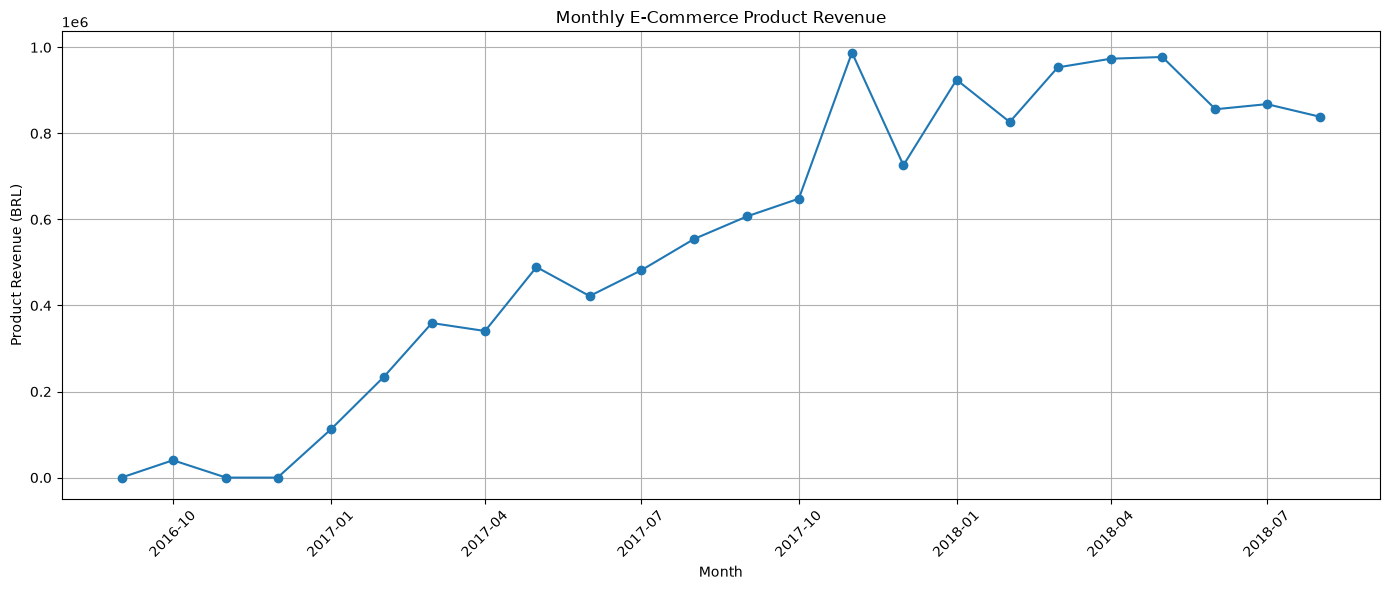

In [20]:

import matplotlib.pyplot as plt

# Calculate monthly product revenue from delivered orders
monthly_sales = (
    delivered_sales
    .set_index("order_purchase_timestamp")
    .resample("MS")["price"]
    .sum()
)

# Display monthly sales
print(monthly_sales)

# Plot monthly sales trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly E-Commerce Product Revenue")
plt.xlabel("Month")
plt.ylabel("Product Revenue (BRL)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



Top 10 Product Categories by Revenue:
product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
Name: price, dtype: float64


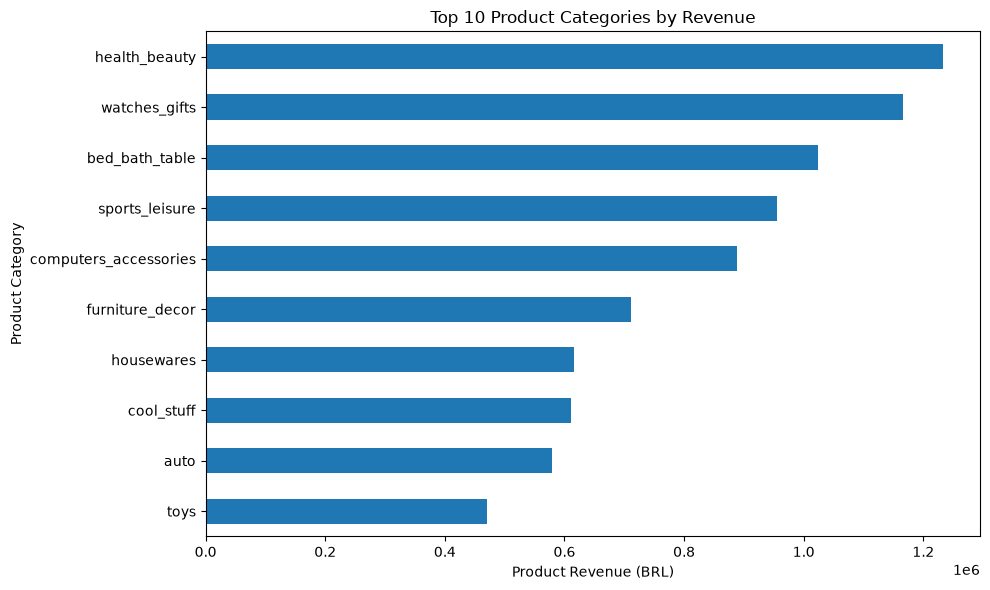

In [21]:
# Analyze revenue by product category

# Add product category information
category_sales = delivered_sales.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Translate category names into English
category_sales = category_sales.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Handle products with missing category names
category_sales["product_category_name_english"] = (
    category_sales["product_category_name_english"]
    .fillna("Unknown")
)

# Calculate revenue by category
category_revenue = (
    category_sales
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 Product Categories by Revenue:")
print(category_revenue.head(10))

# Visualize top 10 categories
category_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 Product Categories by Revenue"
)

plt.xlabel("Product Revenue (BRL)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [22]:
# Analyze customer purchasing behavior

# Merge orders with customer details
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Count delivered orders for each unique customer
delivered_customer_orders = customer_orders[
    customer_orders["order_status"] == "delivered"
]

customer_order_counts = (
    delivered_customer_orders
    .groupby("customer_unique_id")["order_id"]
    .nunique()
)

# Calculate customer behavior metrics
total_delivered_customers = len(customer_order_counts)
repeat_customers = (customer_order_counts > 1).sum()
single_order_customers = (customer_order_counts == 1).sum()

repeat_customer_rate = (
    repeat_customers / total_delivered_customers * 100
)

print("CUSTOMER BEHAVIOR ANALYSIS")
print("--------------------------")
print(f"Delivered Customers: {total_delivered_customers:,}")
print(f"Single-Order Customers: {single_order_customers:,}")
print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")

CUSTOMER BEHAVIOR ANALYSIS
--------------------------
Delivered Customers: 93,358
Single-Order Customers: 90,557
Repeat Customers: 2,801
Repeat Customer Rate: 3.00%


In [24]:
# Analyze customer payment methods

# Count orders associated with each payment method
payment_counts = (
    order_payments
    .groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("PAYMENT METHOD ANALYSIS")
print("-----------------------")
print(payment_counts)

# Calculate payment method percentages
payment_percentages = (
    payment_counts / payment_counts.sum() * 100
).round(2)

print("\nPayment Method Percentage:")
print(payment_percentages)

PAYMENT METHOD ANALYSIS
-----------------------
payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: order_id, dtype: int64

Payment Method Percentage:
payment_type
credit_card    75.24
boleto         19.46
voucher         3.80
debit_card      1.50
not_defined     0.00
Name: order_id, dtype: float64


CUSTOMER REVIEW ANALYSIS
------------------------
Review Score Distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Average Review Score: 4.09 out of 5


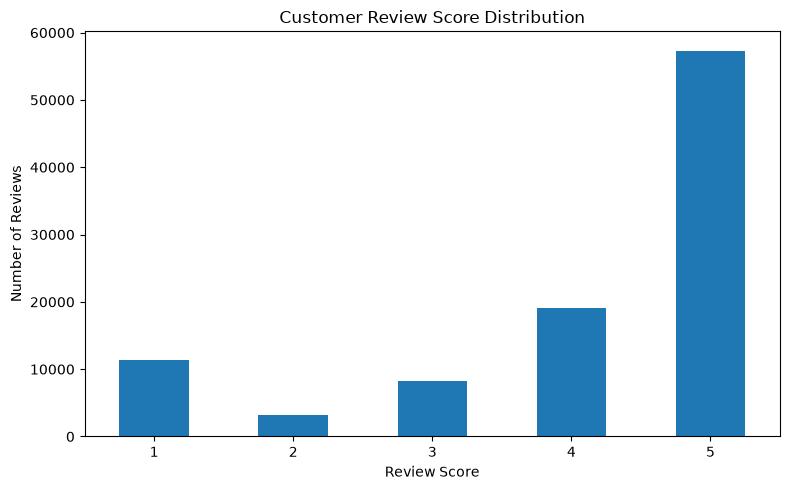

In [25]:
# Analyze customer review scores

# Count reviews for each score
review_counts = (
    order_reviews["review_score"]
    .value_counts()
    .sort_index()
)

print("CUSTOMER REVIEW ANALYSIS")
print("------------------------")
print("Review Score Distribution:")
print(review_counts)

# Calculate average review score
average_review_score = order_reviews["review_score"].mean()

print(f"\nAverage Review Score: {average_review_score:.2f} out of 5")

# Visualize review score distribution
review_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Customer Review Score Distribution"
)

plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Analyze delivery performance

# Keep only delivered orders with valid delivery dates
delivery_data = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_purchase_timestamp"].notna()) &
    (orders["order_delivered_customer_date"].notna()) &
    (orders["order_estimated_delivery_date"].notna())
].copy()

# Calculate actual delivery time in days
delivery_data["actual_delivery_days"] = (
    delivery_data["order_delivered_customer_date"] -
    delivery_data["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

# Calculate estimated delivery difference
# Positive value means delivery was later than estimated
delivery_data["delivery_difference_days"] = (
    delivery_data["order_delivered_customer_date"] -
    delivery_data["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

# Calculate delivery KPIs
average_delivery_days = delivery_data["actual_delivery_days"].mean()

late_deliveries = (
    delivery_data["delivery_difference_days"] > 0
).sum()

on_time_or_early = (
    delivery_data["delivery_difference_days"] <= 0
).sum()

total_valid_deliveries = len(delivery_data)

print("DELIVERY PERFORMANCE ANALYSIS")
print("------------------------------")
print(f"Valid Delivered Orders: {total_valid_deliveries:,}")
print(f"Average Delivery Time: {average_delivery_days:.2f} days")
print(f"Late Deliveries: {late_deliveries:,}")
print(f"On-Time or Early Deliveries: {on_time_or_early:,}")
print(
    f"On-Time/Early Delivery Rate: "
    f"{on_time_or_early / total_valid_deliveries * 100:.2f}%"
)

DELIVERY PERFORMANCE ANALYSIS
------------------------------
Valid Delivered Orders: 96,470
Average Delivery Time: 12.56 days
Late Deliveries: 7,826
On-Time or Early Deliveries: 88,644
On-Time/Early Delivery Rate: 91.89%


In [27]:
# Check columns available for predictive modeling

print("ORDER DATASET COLUMNS:")
print(orders.columns.tolist())

print("\nORDER ITEMS DATASET COLUMNS:")
print(order_items.columns.tolist())

print("\nORDER DATA SAMPLE:")
display(orders.head())

print("\nORDER ITEMS DATA SAMPLE:")
display(order_items.head())


ORDER DATASET COLUMNS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER ITEMS DATASET COLUMNS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

ORDER DATA SAMPLE:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26



ORDER ITEMS DATA SAMPLE:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
